# Machine Learning Models: Supervised and Unsupervised Learning

In this lesson, we will explore various machine learning models, both supervised and unsupervised. 

We will start with linear regression and logistic regression, then move on to support vector machines for classification and regression, and random forests. 

Finally, we will cover K-means clustering and Principal Component Analysis (PCA) as examples of unsupervised learning.


## Group Discussion Question
Why is it important to understand different types of machine learning models? 

How do supervised and unsupervised learning differ in their approach to solving problems? 

Discuss with your group and provide examples of when you might use each type.

# Supervised Learning

## Linear Regression

Linear regression is a simple and commonly used algorithm for predicting a continuous target variable.

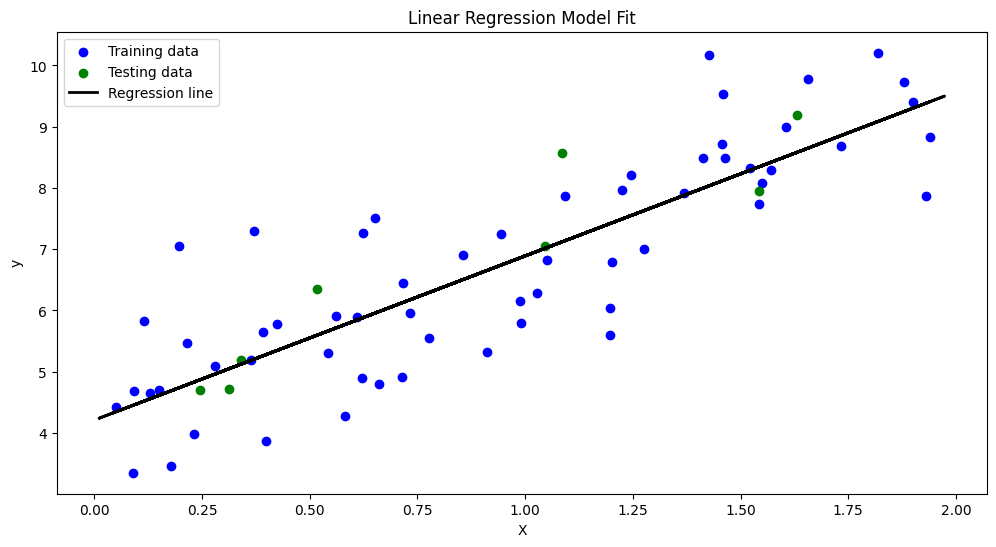

Mean Squared Error on Training Data: 0.9003270465752112
Mean Squared Error on Testing Data: 0.413974620438121


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.2, random_state=42)

# Fit a linear regression model
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

# Predict on the training and testing sets
y_train_pred = linear_reg.predict(X_train)
y_test_pred = linear_reg.predict(X_test)

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Testing data')
plt.plot(X, linear_reg.predict(X), color='black', linewidth=2, label='Regression line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression Model Fit')
plt.show()

# Calculate and print mean squared errors
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f'Mean Squared Error on Training Data: {mse_train}')
print(f'Mean Squared Error on Testing Data: {mse_test}')

## Logistic Regression
Logistic regression is used for binary classification problems.

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = (iris.target == 0).astype(int)  # Binary classification: Setosa or not

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predict on the testing set
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(classification_report(y_test, y_pred))


Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Support Vector Machines (SVM)
Support vector machines are powerful tools for both classification and regression tasks. They develop an optimal hyperplane through data in an n-dimensional space.

### SVC

In [4]:
from sklearn.svm import SVC

# Fit an SVM model for classification
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

# Predict on the testing set
y_pred_svm = svm_clf.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f'Accuracy (SVM): {accuracy_svm}')
print('Classification Report (SVM):')
print(classification_report(y_test, y_pred_svm))

Accuracy (SVM): 1.0
Classification Report (SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### SVR

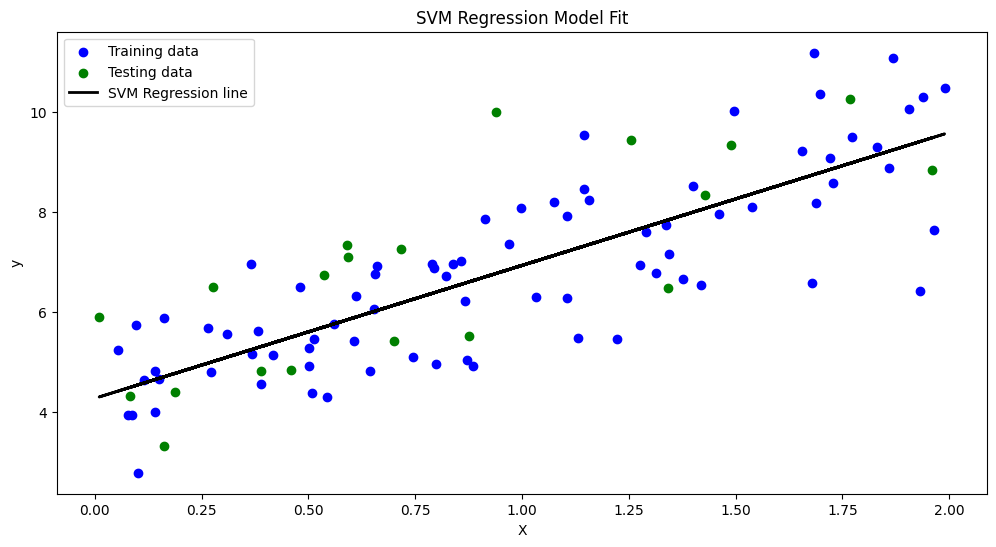

In [5]:
from sklearn.svm import SVR

# Generate synthetic data for regression
X_svr = 2 * np.random.rand(100, 1)
y_svr = 4 + 3 * X_svr + np.random.randn(100, 1)

# Split the data into training and testing sets
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_svr, y_svr, test_size=0.2, random_state=42)

# Fit an SVM model for regression
svr_reg = SVR(kernel='linear')
svr_reg.fit(X_train_svr, y_train_svr.ravel())

# Predict on the testing set
y_pred_svr = svr_reg.predict(X_test_svr)

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(X_train_svr, y_train_svr, color='blue', label='Training data')
plt.scatter(X_test_svr, y_test_svr, color='green', label='Testing data')
plt.plot(X_svr, svr_reg.predict(X_svr), color='black', linewidth=2, label='SVM Regression line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('SVM Regression Model Fit')
plt.show()


## Random Forest

Random forests are ensemble learning methods that combine multiple decision trees to improve performance.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Fit a random forest model for classification
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predict on the testing set
y_pred_rf = rf_clf.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy (Random Forest): {accuracy_rf}')
print('Classification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf))

Accuracy (Random Forest): 1.0
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Unsupervised Learning

## K-Means Clustering

K-means clustering is an unsupervised learning algorithm used for partitioning a dataset into clusters.

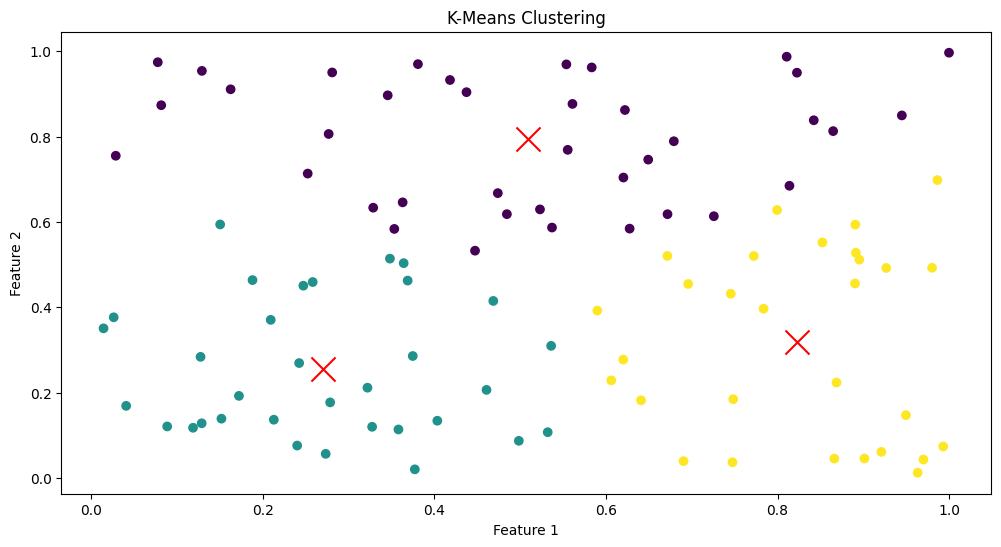

In [7]:
from sklearn.cluster import KMeans

# Generate synthetic data
X_kmeans = np.random.rand(100, 2)

# Fit a K-means model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_kmeans)

# Predict the clusters
clusters = kmeans.predict(X_kmeans)

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.show()

## Principal Component Analysis (PCA)

PCA is an unsupervised learning algorithm used for dimensionality reduction.

It may turn out that we have separation in a lower dimensional space - not requiring all of the information at a higher level that may overlap and hinder prediction if there is dependence. 

Principal components are orthogonal by construction.

Petal Length Petal Width Sepal Length Sepal Width
Reducing the Dimensionality to 2 and Coloring for Segmentation


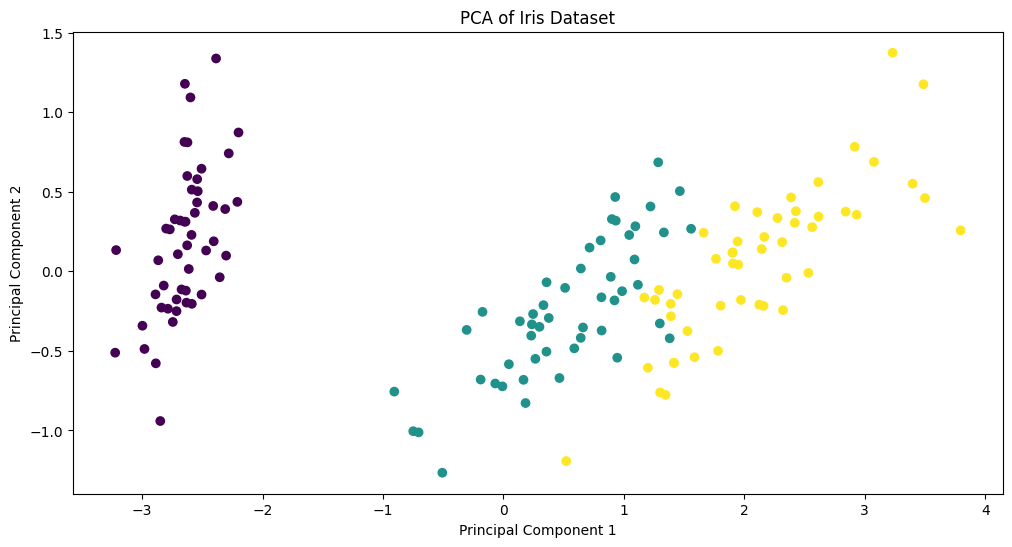

In [8]:
from sklearn.decomposition import PCA

# Load dataset
X_pca = iris.data

print('Petal Length', 'Petal Width', 'Sepal Length', 'Sepal Width')
print('Reducing the Dimensionality to 2 and Coloring for Segmentation')

# Fit a PCA model
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_pca)

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=iris.target, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.show()


## Practice Problems
1. Explain the difference between linear regression and logistic regression. Provide an example of when you would use each.

2. Describe the key concepts behind support vector machines. How do they differ when used for classification versus regression?

3. What are the advantages of using random forests over individual decision trees? Discuss a scenario where a random forest might be more effective.

4. Define K-means clustering and PCA. How are they used in unsupervised learning, and what are their main applications?

## Extensions

### Hyperparameter Tuning
Explore how to tune hyperparameters for support vector machines and random forests to improve model performance. E.g.) How many clusters do we use for K-means? Very problem dependent.

### Combining PCA with Other Algorithms

Show how PCA can be combined with other algorithms like logistic regression to improve performance on high-dimensional datasets.


# Conclusion

In this lesson, we explored various machine learning models, both supervised and